##1.Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [ ]:
wine = pd.read_csv("winequality-red.csv",sep=";")

print(wine.head())
print(wine.shape)
print(wine.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

###2.EDA: distribution plots + correlation heatmap

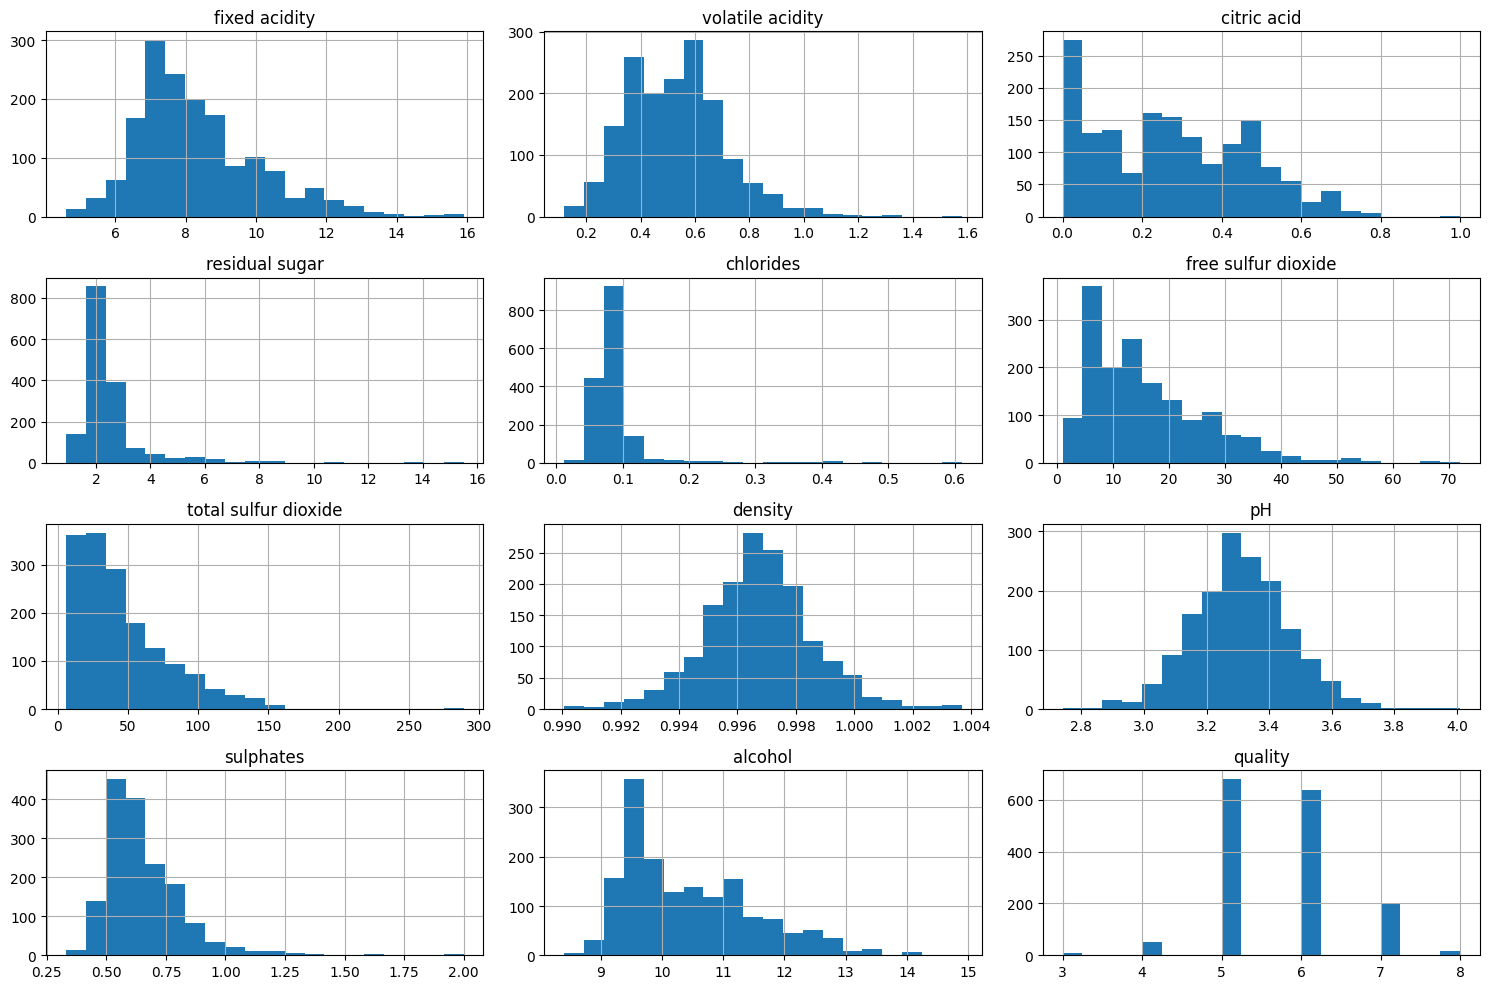

In [ ]:
wine.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

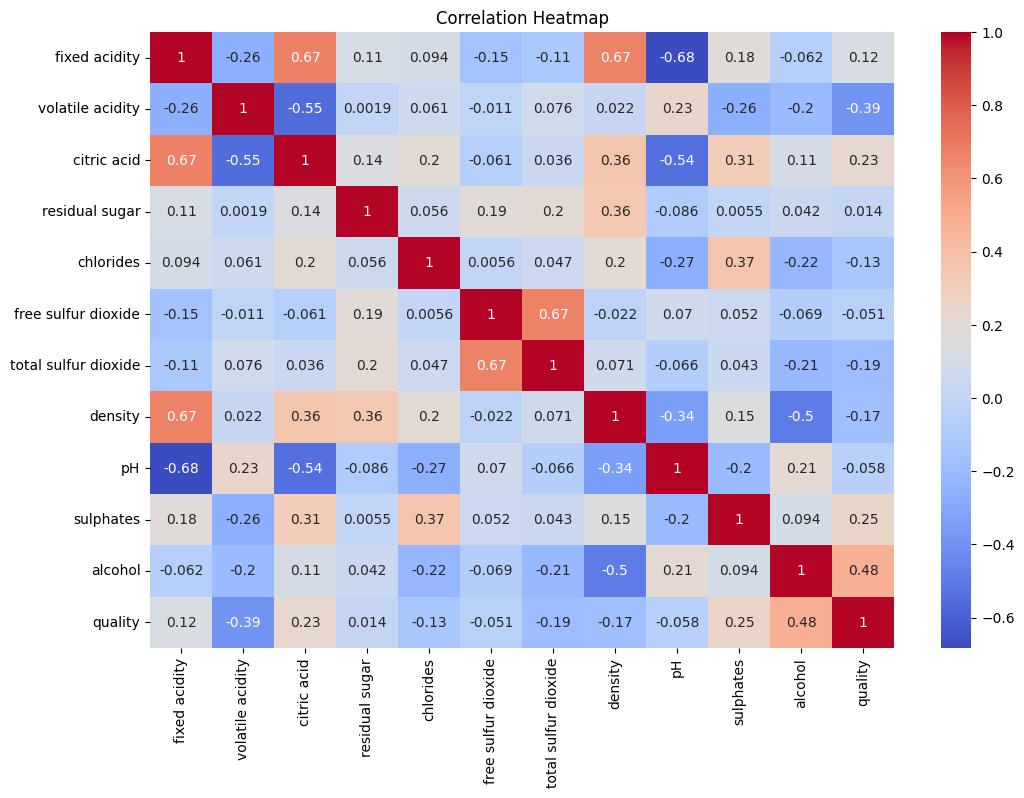

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(wine.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

###3.Class Imbalance

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


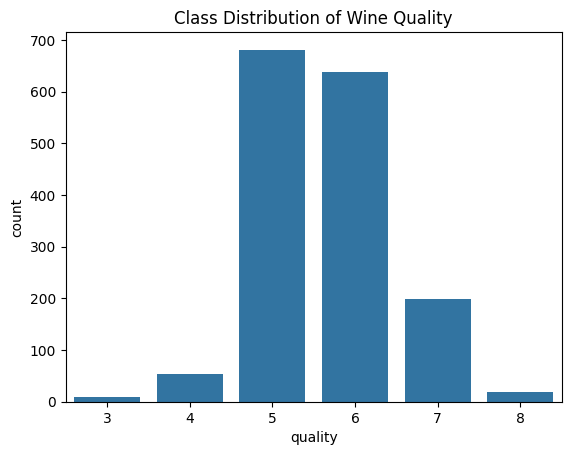

In [ ]:
print(wine["quality"].value_counts().sort_index())

sns.countplot(x="quality", data=wine)
plt.title("Class Distribution of Wine Quality")
plt.show()

###4.Feature Engineering

In [ ]:
def quality_group(x):
    if x <= 4:
        return 0
    elif x <= 6:
        return 1
    else:
        return 2

wine["quality_group"] = wine["quality"].apply(quality_group)

print(wine["quality_group"].value_counts())

quality_group
1    1319
2     217
0      63
Name: count, dtype: int64


###5.Train/test split with stratification

In [ ]:
X = wine.drop(["quality", "quality_group"], axis=1)
y = wine["quality_group"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

###6.Train 3 classifiers

In [ ]:
#random forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
#SGD
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd = SGDClassifier(random_state=42)

sgd.fit(X_train_scaled, y_train)

sgd_pred = sgd.predict(X_test_scaled)

In [ ]:
#svc
svc = SVC()

svc.fit(X_train_scaled, y_train)

svc_pred = svc.predict(X_test_scaled)

###7.accuracy and classification report

In [ ]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

print("SGD Accuracy:")
print(accuracy_score(y_test, sgd_pred))
print(classification_report(y_test, sgd_pred))

print("SVC Accuracy:")
print(accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))

Random Forest Accuracy:
0.8875
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.90      0.97      0.93       264
           2       0.78      0.65      0.71        43

    accuracy                           0.89       320
   macro avg       0.56      0.54      0.55       320
weighted avg       0.85      0.89      0.87       320

SGD Accuracy:
0.83125
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.86      0.95      0.90       264
           2       0.61      0.33      0.42        43

    accuracy                           0.83       320
   macro avg       0.49      0.43      0.44       320
weighted avg       0.79      0.83      0.80       320

SVC Accuracy:
0.85
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.87      0.96      0.91       264
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

###8.confusion matrix


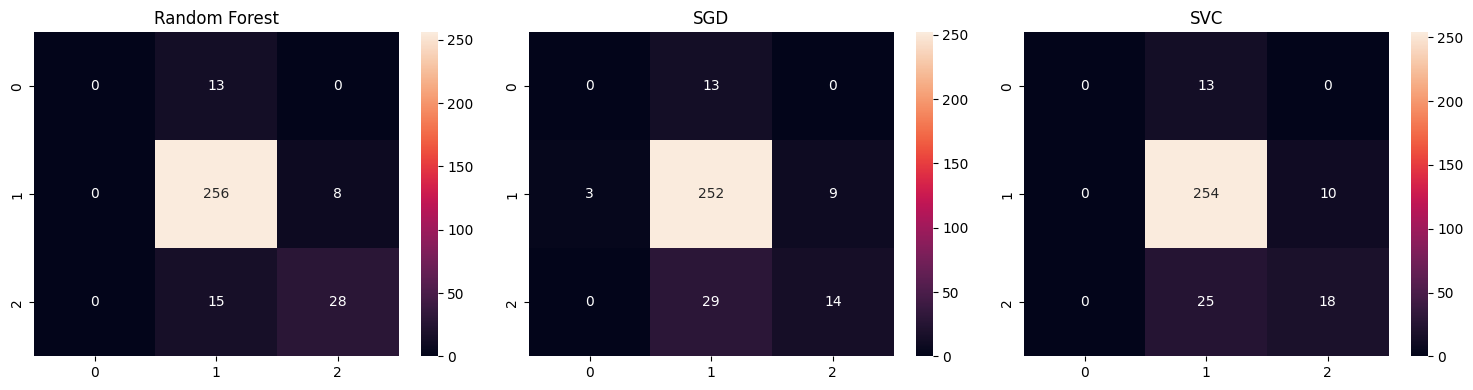

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Random Forest")

sns.heatmap(confusion_matrix(y_test, sgd_pred), annot=True, fmt="d", ax=axes[1])
axes[1].set_title("SGD")

sns.heatmap(confusion_matrix(y_test, svc_pred), annot=True, fmt="d", ax=axes[2])
axes[2].set_title("SVC")

plt.tight_layout()
plt.show()

###9.Random Forest feature importance

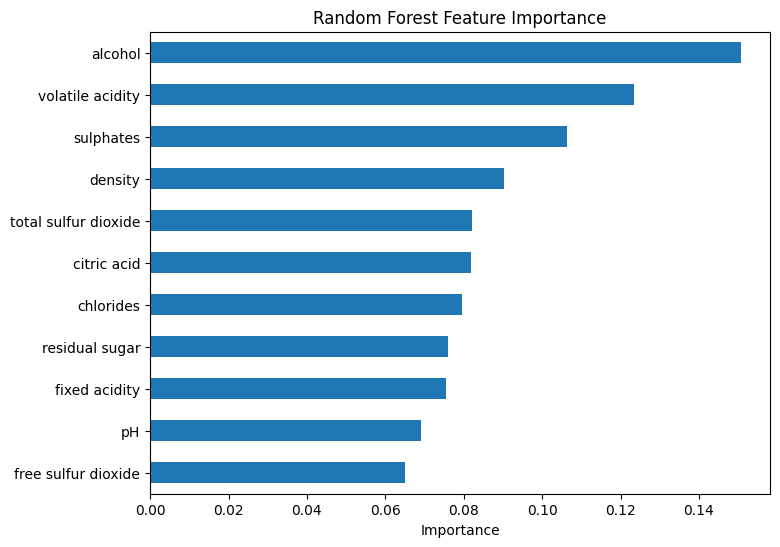

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

importance.plot(kind="barh", figsize=(8, 6))

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

###10.model comparision

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ]
})

print(results)

           Model  Accuracy
0  Random Forest   0.88750
1            SGD   0.83125
2            SVC   0.85000


### Conclusion

Three models—Random Forest, SGD, and SVC—were used to predict wine quality. Among them, **the model with the highest accuracy performed best** and is most suitable for deployment. The analysis also showed that chemical properties such as alcohol and acidity influence wine quality.
